In [ ]:
import os
import ee
import json
import geemap
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from sqlalchemy import create_engine
from dotenv import load_dotenv
from shapely.geometry import shape

load_dotenv(dotenv_path="./.env")

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)

DB_PASSWORD = os.environ.get('DB_PASSWORD')
DB_IP = os.environ.get('DB_IP')

ee.Initialize()

In [ ]:
# Import market shapes from the database
engine = create_engine(f"mysql+mysqlconnector://root:{DB_PASSWORD}@{DB_IP}:3306/mai-database")
query = "SELECT Location, marketDays, maxSignal, mktShape FROM location_file WHERE country = 'Mali' AND mktShape IS NOT NULL"
df = pd.read_sql(query, engine)

def extract_geometry_from_mktShape(mktShape):
    # Parse the mktShape string to dict if needed
    if isinstance(mktShape, str):
        mktShape = json.loads(mktShape)
    # Get the first weekday's geometry
    weekday = next(iter(mktShape.values()))
    # Use the first feature's geometry
    geom = weekday['features'][0]['geometry']
    return shape(geom)

df['geometry'] = df['mktShape'].apply(extract_geometry_from_mktShape)
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs='EPSG:4326')

In [335]:
gdf_ee = geemap.geopandas_to_ee(gdf)

In [346]:
# Import prediction and diffImg data from Earth Engine
cell = 110

preds = ee.FeatureCollection(f"projects/mali-candidate-locs/assets/S2/cnn_predictions/ConvNeXt_transfer/20250520_1230/predictions_cell_{cell}")
preds_old = ee.FeatureCollection(f"projects/mali-candidate-locs/assets/S2/cnn_predictions/siamese_fusion_anymarket_2/20250211/predictions_cell_{cell}")
diffImg = ee.ImageCollection("projects/mali-candidate-locs/assets/diffImgAll_norm5k")

# Define visualization parameters for a continuous palette
vis_params = {
    'min': 0,
    'max': 1,
    'palette': ['#440154', '#21908d', '#fde725']  # Viridis palette, feel free to change
}

# Convert FeatureCollection to an image (necessary for coloring polygons)
image_preds = preds.filter(ee.Filter.gt('prediction', 0.5)).reduceToImage(properties=['prediction'], reducer=ee.Reducer.first())
image_preds_old = preds_old.filter(ee.Filter.gt('prediction', 0.5)).reduceToImage(properties=['prediction'], reducer=ee.Reducer.first())

# Create an interactive map
Map = geemap.Map()
Map.add_basemap('SATELLITE')
Map.addLayer(diffImg, {"max": 7}, 'Diff Image', False)
Map.addLayer(image_preds, vis_params, 'Prediction')
Map.addLayer(image_preds_old, vis_params, 'Old Prediction', False)
Map.addLayer(gdf_ee, {"color": "red"}, 'Market Shapes')
Map.center_object(preds, 12)
Map.add_colorbar(vis_params, label='Prediction value')
Map

Map(center=[13.551589763131046, -6.497413129428759], controls=(WidgetControl(options=['position', 'transparent…

In [ ]:
from data_loader import TFDatasetBuilder
from keras.applications.convnext import ConvNeXtTiny, LayerScale
from data_loader import read_tif, preprocess_new_data
import keras
import pickle
import matplotlib.pyplot as plt
import numpy as np

with open('models/ConvNeXt_transfer/20250520_1230/scaler.pkl', 'rb') as file:
    scaler = pickle.load(file)

# Load model
model_path = "models/ConvNeXt_transfer/20250520_1230/checkpoints/best_model.keras"
model = keras.models.load_model(
    model_path,
    custom_objects={"ConvNeXtTiny": ConvNeXtTiny, "LayerScale": LayerScale}
)

In [319]:
new_data.shape

(128, 128, 7)

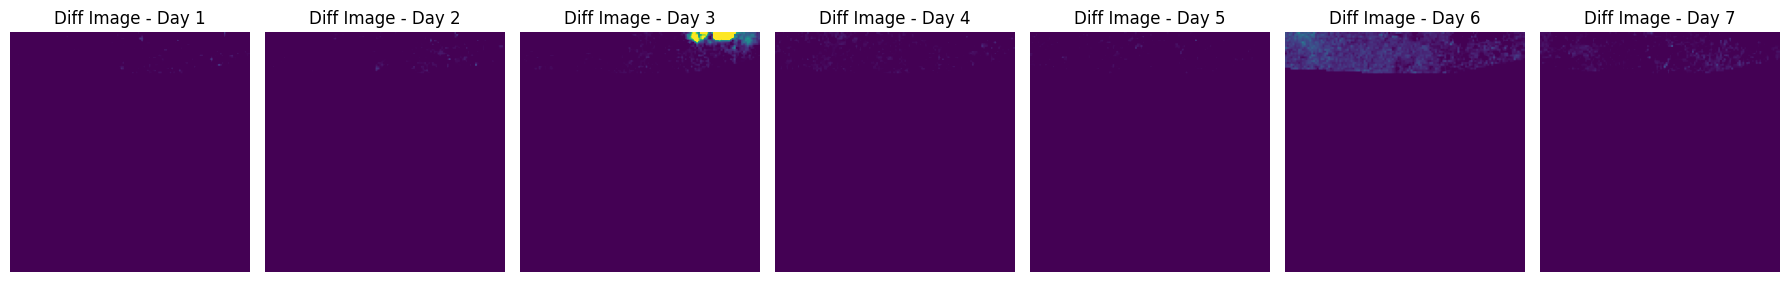

In [325]:
def display_diffImg(arr, title_prefix="Diff Image"):
    """
    Display all 7 days (channels) of a (H, W, 7) or (1, H, W, 7) array as subplots.
    The color scale is fixed with vmin=0 and vmax=1.
    """
    if arr.ndim == 4 and arr.shape[0] == 1:
        arr = arr[0]
    fig, axes = plt.subplots(1, 7, figsize=(18, 3))
    for i in range(7):
        axes[i].imshow(arr[:, :, i], cmap='viridis', vmin=0, vmax=1)
        axes[i].set_title(f"{title_prefix} - Day {i+1}")
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

display_diffImg(new_data)

In [ ]:
show_all_days(arr, title_prefix="Array")

1/1 [==============================] - 0s 233ms/step
Prediction from dataloader array: 0.7513641
1/1 [==============================] - 0s 144ms/step
Prediction from tif array: 0.7513641
Comparison of sums of arrays: 38.086853 38.08685


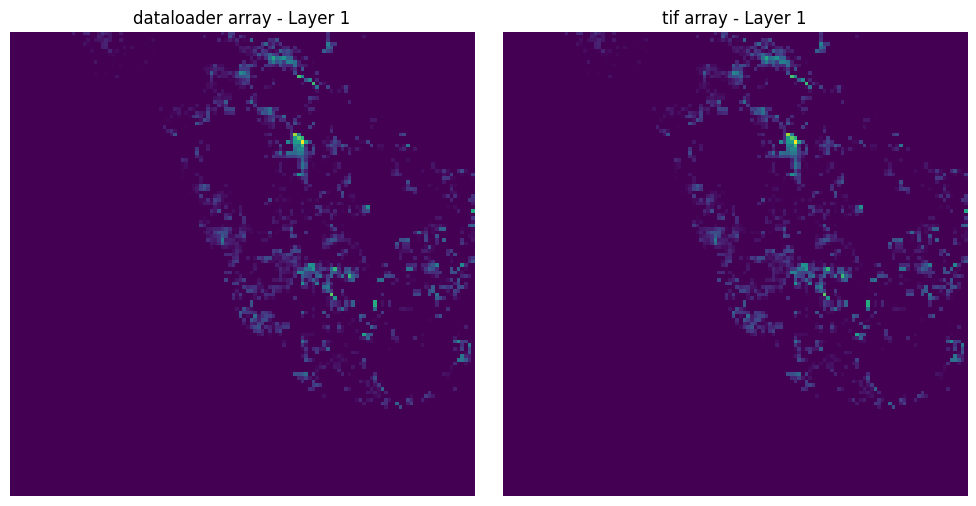

In [311]:
#loc = 'lon-0_0107lat37_6608'
loc = 'lon-10_6827lat13_1612'
metadata = pd.read_csv("./data/training_data_S2/image_metadata.csv")
metadata["Location"] = metadata["image_file_path"].str.extract(r'(lon-?[^_]+_[^_]+lat-?[^_]+_[^_]+)')
one = metadata[metadata['Location'] == loc].head(1)
one.to_csv("./data/training_data_S2/image_metadata_one.csv", index=False)

# Import market shapes from the database
engine = create_engine(f"mysql+mysqlconnector://root:{DB_PASSWORD}@{DB_IP}:3306/mai-database")
query = f"SELECT Location, marketDays, maxSignal, mktShape FROM location_file WHERE Location = '{loc}'"
df = pd.read_sql(query, engine)

def extract_geometry_from_mktShape(mktShape):
    # Parse the mktShape string to dict if needed
    if isinstance(mktShape, str):
        mktShape = json.loads(mktShape)
    # Get the first weekday's geometry
    weekday = next(iter(mktShape.values()))
    # Use the first feature's geometry
    geom = weekday['features'][0]['geometry']
    return shape(geom)

df['geometry'] = df['mktShape'].apply(extract_geometry_from_mktShape)
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs='EPSG:4326')

builder = TFDatasetBuilder(
    csv_path="./data/training_data_S2/image_metadata_one.csv",
    scaling="minmax",
    do_augmentation=False,
    do_clipping=True,
    lower_clip=0,
    upper_clip=40,
)

train_ds, val_ds, test_ds = builder.build_datasets(
    train_split=0.70,
    val_split=0.15,
    sample_size=1000,  # number of images for p1/p99 & robust scaling
    batch_size=16,
    shuffle_buffer=256,
)

for images, labels in test_ds.take(1):
    arr_dl = images[0].numpy()

pred_dl = model.predict(images)
print("Prediction from dataloader array:", pred_dl[0][0])

arr_tif = read_tif(one.iloc[0]['image_file_path'])
arr_tif = preprocess_new_data(arr_tif, scaler=scaler, do_clipping=True, lower_clip=0, upper_clip=40)
arr_tif = np.transpose(arr_tif, (3, 1, 2, 0))
preds_tif = model.predict(arr_tif)
print("Prediction from tif array:", preds_tif[0][0])

print("Comparison of sums of arrays:", np.sum(arr_dl), np.sum(arr_tif))

# Visualize the first channel (layer 1) of arr_reshaped and array side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(arr_dl[:, :, 2], cmap='viridis')
axes[0].set_title('dataloader array - Layer 1')
axes[0].axis('off')

axes[1].imshow(arr_tif[0, :, :, 2], cmap='viridis')
axes[1].set_title('tif array - Layer 1')
axes[1].axis('off')

plt.tight_layout()
plt.show()


In [312]:
# Convert GeoDataFrame to Earth Engine FeatureCollection using geemap
marketShp_ee = geemap.geopandas_to_ee(gdf)

# Filter diffImgAll to images that overlap with the geometry of gdf
diffImgAll = ee.ImageCollection('projects/mali-candidate-locs/assets/diffImgAll')
diffImg = diffImgAll.filterBounds(marketShp_ee).first()

In [ ]:
tile_size = 128 
pixel_size = 10
tile_length = pixel_size * tile_size
image_geo = diffImg.geometry()

# Create an offset grid covering the country
grid = image_geo.coveringGrid(proj=ee.Projection('EPSG:4326').atScale(tile_length))
offset_grid = image_geo.buffer(tile_size*pixel_size*0.5) \
    .coveringGrid(proj=ee.Projection('EPSG:4326') \
    .translate(tile_length, tile_length) \
    .atScale(tile_length))
total_grid = grid.merge(offset_grid)

# Create a mask of where the image exceeds 2
high_pixels = diffImg.select('max_all').gt(2).selfMask()

high_pixels_geo = high_pixels.reduceToVectors(
    scale = 10,
    geometry = image_geo,
    maxPixels = 1e12,
    reducer = ee.Reducer.countEvery()
).geometry()

# Filter the grid to only include the high pixels
high_pixels_grid = total_grid.filterBounds(high_pixels_geo)

# Convert high_pixels_grid to GeoJSON
high_pixels_grid_geojson = high_pixels_grid.getInfo()

# Convert GeoJSON to GeoPandas DataFrame
gdf = gpd.GeoDataFrame.from_features(high_pixels_grid_geojson['features'])

In [326]:
def predict_gdf_batch(gdf, image, model, scaler, args):
    processed_data_list = []

    for i in range(len(gdf)):
        ee_fc = geemap.geopandas_to_ee(gdf.iloc[[i]].set_crs("EPSG:4326"))
        geometry = ee_fc.geometry()
        image_data = get_image_data(image, geometry)
        processed_data = preprocess_new_data(image_data, scaler=scaler, do_clipping=args.do_clipping, lower_clip=args.lower_clip, upper_clip=args.upper_clip)
        processed_data = processed_data.squeeze(-1)
        processed_data_list.append(processed_data)

    if processed_data_list:
        # Stack all image data into a single numpy array
        batch_data = np.stack(processed_data_list)

        # Predict the data
        predictions = model.predict(batch_data)
        
        # Add predictions to the GeoDataFrame
        gdf['prediction'] = predictions

    return gdf

def get_image_data(image, geometry, scale=10):
    # Clip the image to the specified geometry
    clipped_image = image.clip(geometry).unmask(ee.Image.constant(0))
    
    # Get the image data as a numpy array
    url = clipped_image.getDownloadURL({
        'scale': scale, 
        'format': 'NPY',
        'bands': [
            {'id':'weekday_0', 'scale':scale},
            {'id':'weekday_1', 'scale':scale},
            {'id':'weekday_2', 'scale':scale},
            {'id':'weekday_3', 'scale':scale},
            {'id':'weekday_4', 'scale':scale},
            {'id':'weekday_5', 'scale':scale},
            {'id':'weekday_6', 'scale':scale}
            ]
        })

    response = requests.get(url)
    data = np.load(BytesIO(response.content))

    # Reshape the data to have the shape (7, 128, 128)
    new_data = data[['weekday_0', 'weekday_1', 'weekday_2', 'weekday_3', 'weekday_4', 'weekday_5', 'weekday_6']]
    new_data = new_data.view((float, len(new_data.dtype.names))).reshape(data.shape[0], data.shape[1], 7)
    
    # Check if the data shape is at least (_, 128, 128)
    if new_data.shape[0] < 128 or new_data.shape[1] < 128:
        # Calculate the padding sizes and pad with 0s
        pad_width = ((0, 0), (0, max(0, 128 - new_data.shape[0])), (0, max(0, 128 - new_data.shape[1])))
        new_data = np.pad(new_data, pad_width, mode='constant', constant_values=0)

    new_data = new_data[:128, :128, :]

    if new_data.shape[0] != 128 or new_data.shape[1] != 128 or new_data.shape[2] != 7:
        print(f"Error: Unexpected shape {new_data.shape}, expected (128, 128, 7). Returning zeros.")
        return np.zeros((128, 128, 7), dtype=new_data.dtype)

    return new_data

predictions_gdf = predict_gdf_batch(gdf, diffImg, model, scaler, args)
preds_ee = geemap.geopandas_to_ee(predictions_gdf.set_crs("EPSG:4326"))

Error: Unexpected shape (128, 66, 69), expected (128, 128, 7). Returning zeros.
3/3 [==============================] - 5s 1s/step


In [328]:
# Define visualization parameters for a continuous palette
vis_params = {
    'min': 0,
    'max': 1,
    'palette': ['#440154', '#21908d', '#fde725']  # Viridis palette, feel free to change
}

# Convert FeatureCollection to an image (necessary for coloring polygons)
image_preds = preds.filter(ee.Filter.gt('prediction', 0.5)).reduceToImage(properties=['prediction'], reducer=ee.Reducer.first())
image_preds_old = preds_old.filter(ee.Filter.gt('prediction', 0.5)).reduceToImage(properties=['prediction'], reducer=ee.Reducer.first())
image_preds_fixed = preds_ee.filter(ee.Filter.gt('prediction', 0.1)).reduceToImage(properties=['prediction'], reducer=ee.Reducer.first())

# Create an interactive map
Map = geemap.Map()
Map.addLayer(diffImg, {"max": 7}, 'Diff Image')
#Map.addLayer(image_preds, vis_params, 'Prediction')
Map.addLayer(image_preds_old, vis_params, 'Old Prediction')
Map.addLayer(image_preds_fixed, vis_params, 'Predictions Fixed')
Map.addLayer(marketShp_ee, {'color': 'red', 'fillColor': 'red', 'fillOpacity': 0.5}, 'Markets')

Map.center_object(marketShp_ee, 12)

Map.add_colorbar(vis_params, label='Prediction value')

Map

Map(center=[13.161186870632399, -10.682787855141354], controls=(WidgetControl(options=['position', 'transparen…